# Seismic signals preprocessing and exploration

This notebook covers the loading, preprocessing, and exploratory analysis of seismic signals.

Two separate preprocessing pipelines are applied:

1. **Pipeline A (PDF analysis)**: Applied to all signals with baseline correction and normalization. The normalized data is used for PDF analysis, heavy-tail assessment, and cross-station comparisons of distribution shapes.

2. **Pipeline B (Moment scaling analysis)**: Applied to all signals with baseline correction but **without normalization**. This preserves physical units, which is essential for moment scaling analysis.

**Key difference**: Pipeline A creates both the raw signal column and its normalized version, while Pipeline B creates only the raw signal column (preserving physical units).

## 1. Imports and visualization settings

In [37]:
from pathlib import Path
import pandas as pd
import numpy as np
import logging
from src import (
    build_signals,
    preprocess_signals,
    validate_preprocessing,
    set_plot_style,
    preprocess_checks_to_latex,
    plot_signal_length_distribution,
    plot_station_waveforms,
    plot_signals_distributions,
    plot_postcheck_pdf,
    plot_postcheck_moment_scaling)
from IPython.display import display
colors = set_plot_style()
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger()
def check(condition, message):
    if condition:
        logger.info(message)
    else:
        raise ValueError(message)
logger.info("Environment ready")

INFO | Environment ready


## 2. Configuration

In [38]:
# CONFIGURATION
DATA_TYPE = 'displacement'  # Options: 'acceleration', 'velocity', 'displacement'

# Determine signal column name based on DATA_TYPE
if DATA_TYPE == 'acceleration':
    SIGNAL_COLUMN = 'acceleration'
    SIGNAL_UNIT = 'cm/s²'
elif DATA_TYPE == 'velocity':
    SIGNAL_COLUMN = 'velocity'
    SIGNAL_UNIT = 'cm/s'
elif DATA_TYPE == 'displacement':
    SIGNAL_COLUMN = 'displacement'
    SIGNAL_UNIT = 'cm'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

In [39]:
# Get project root
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent.parent

# Define all paths from project root
DATA_RAW = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed' / '01b_signals' / DATA_TYPE
FIGURES_DIR = PROJECT_ROOT / 'figures' / '01b_signals' / DATA_TYPE
LATEX_TABLES_DIR = PROJECT_ROOT / 'data' / 'processed' / 'latex_tables' / DATA_TYPE

# Create output directories
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LATEX_TABLES_DIR.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

check(FIGURES_DIR.exists(), f"Figures directory ready: {FIGURES_DIR}")
check(LATEX_TABLES_DIR.exists(), f"LaTeX tables directory ready: {LATEX_TABLES_DIR}")
check(DATA_PROCESSED.exists(), f"Processed data directory ready: {DATA_PROCESSED}")

INFO | Figures directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement
INFO | LaTeX tables directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/displacement
INFO | Processed data directory ready: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01b_signals/displacement


## 3. Data loading

Raw data are loaded from the zip archive containing the `.ASC` files.
The function `build_signals` extracts the acceleration time series from 
each file and returns a dataframe with columns `file`, `sample`, and `acceleration`.

In [40]:
# Load data
logger.info(f"Loading {DATA_TYPE} data...")

# Determine zip filename based on data type
if DATA_TYPE == 'acceleration':
    zip_filename = 'query_acc.zip'
elif DATA_TYPE == 'velocity':
    zip_filename = 'query_vel.zip'
elif DATA_TYPE == 'displacement':
    zip_filename = 'query_disp.zip'
else:
    raise ValueError(f"Unknown DATA_TYPE: {DATA_TYPE}")

df_signals = build_signals(DATA_RAW / zip_filename, signal_type=SIGNAL_COLUMN)
df_meta = pd.read_parquet(PROJECT_ROOT / 'data' / 'processed' / '01a_metadata' / DATA_TYPE / f'metadata_clean_{DATA_TYPE[:3]}.parquet')

# Check if metadata was loaded successfully
check(df_meta is not None, "Metadata dataframe created")
check(len(df_meta) > 0, "Metadata dataframe is not empty")
logger.info(f"Metadata dataframe loaded, shape: {df_meta.shape}\n")

# Check if signals were loaded successfully
check(df_signals is not None, f"{DATA_TYPE.capitalize()} dataframe created")
check(len(df_signals) > 0, f"{DATA_TYPE.capitalize()} dataframe is not empty")
logger.info(f"{DATA_TYPE.capitalize()} dataframe loaded, shape: {df_signals.shape}\n")

INFO | Loading displacement data...
INFO | Metadata dataframe created
INFO | Metadata dataframe is not empty
INFO | Metadata dataframe loaded, shape: (66, 38)

INFO | Displacement dataframe created
INFO | Displacement dataframe is not empty
INFO | Displacement dataframe loaded, shape: (2614815, 3)



## 4. Exploration

A first exploration of the raw signals is performed to understand 
the structure of the dataset before preprocessing. Signal lengths, amplitude distributions, and waveforms are inspected.

### Signal length distribution

The number of samples varies across signals. Understanding the distribution of signal lengths is important for deciding how to handle signals of different lengths.

INFO | Plotting signal length distribution...
INFO | N files: 66 — lengths range: 6000–56000 samples


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/signal_length_distribution_dis.pdf


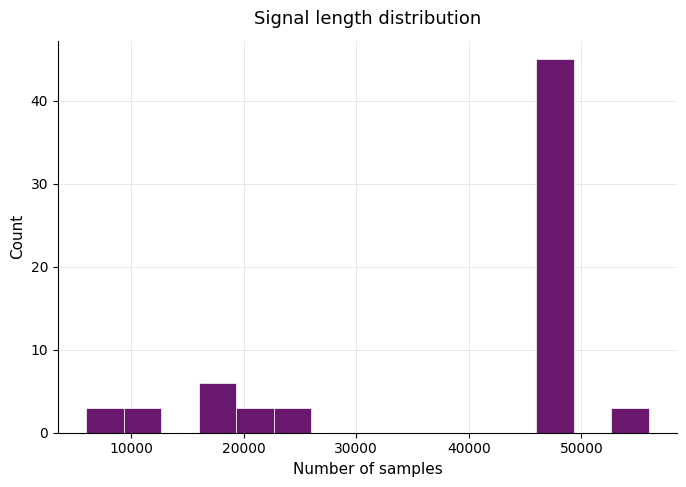

In [41]:
logger.info("Plotting signal length distribution...")
signal_lengths = df_signals.groupby('file')['sample'].max() + 1
logger.info(f"N files: {len(signal_lengths)} — lengths range: "
            f"{signal_lengths.min()}–{signal_lengths.max()} samples")
plot_signal_length_distribution(signal_lengths, output_dir=FIGURES_DIR, prefix=DATA_TYPE[:3])

### Signal distribution

The distribution of signal values is visualized on a logarithmic scale to better appreciate the heavy tails of the distribution. The dominance of near-zero values reflects the long pre-event and post-event noise windows.

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/signal_distribution_dis.pdf


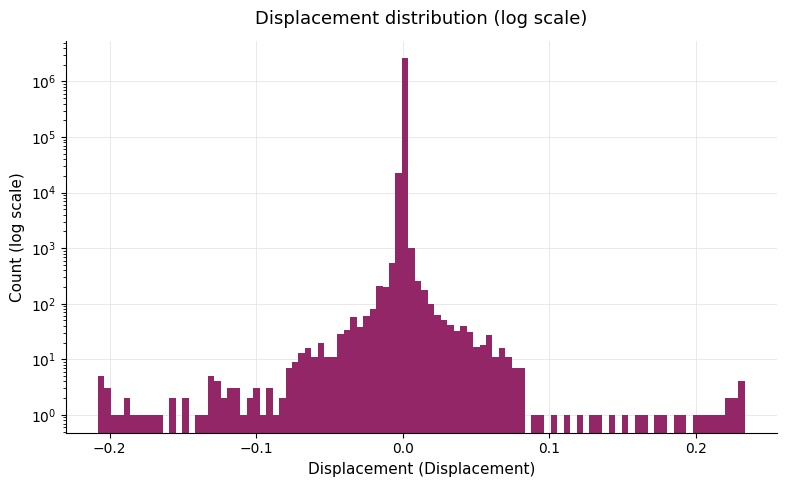

Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/signal_by_component_dis.pdf


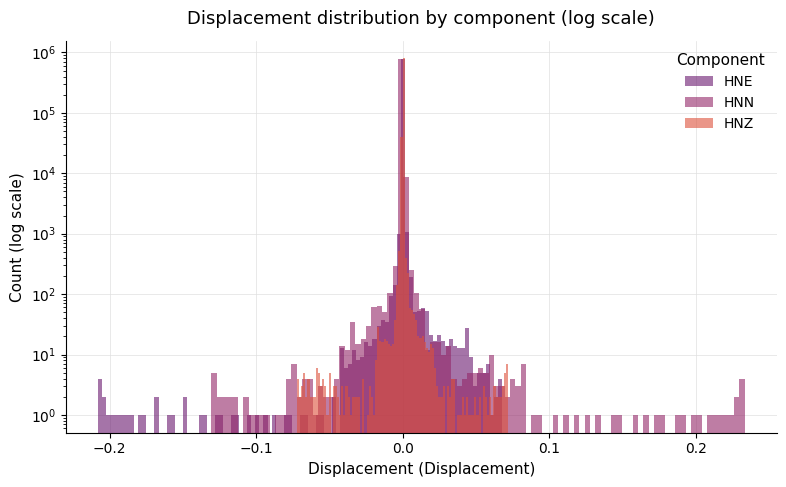

In [42]:
plot_signals_distributions(
    df_signals, df_meta, 
    signal_column=SIGNAL_COLUMN,
    signal_unit=SIGNAL_UNIT if DATA_TYPE == 'acceleration' else DATA_TYPE.capitalize(),
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3]
)

## 5. Preprocessing for PDF analysis

The PDF analysis pipeline is designed to enable cross-station comparison of distribution shapes by normalizing signals to a common scale. The pipeline offers independent control over three preprocessing steps:

**Available preprocessing options:**

1. **Length filtering** (`filter_length` parameter)
   - If `True`: Retains only signals with ≥ `min_samples` (default: 48,000). Useful when long time scales are required.
   - If `False`: Uses all available signals regardless of length. Recommended for PDF analysis to maximize statistical sample size.

2. **Baseline correction** (`baseline_correction` parameter)
   - If `True`: Removes per-signal mean to ensure zero baseline. Recommended always to eliminate systematic offsets.
   - If `False`: Keeps original baseline (not recommended).

3. **Normalization** (`normalize` parameter)
   - If `True`: Divides each signal by its standard deviation, creating an additional normalized column. Essential for PDF analysis to enable fair cross-station comparisons.
   - If `False`: Preserves physical units (not suitable for comparing signals with different amplitudes).

**Critical choice**: Normalization must be enabled for PDF analysis to remove amplitude differences and focus on distribution shape characteristics (heavy tails, asymmetry, etc.).

In [43]:
logger.info("Preprocessing signals — PDF analysis pipeline")
df_signals_pdf = preprocess_signals(
    df_signals,
    signal_column=SIGNAL_COLUMN,
    filter_length=False,        # Use all 66 files
    baseline_correction=True,   # Remove baseline
    normalize=True              # Normalize for PDF comparison
)

INFO | Preprocessing signals — PDF analysis pipeline


Length filtering: DISABLED (using all 66 files)
Baseline correction: max residual mean = 6.46e-20
Normalization: mean std = 1.0000000000 (expected: 1.0)


### Post-preprocessing check and saving

The preprocessed dataframe is inspected to verify that baseline correction and normalization have been applied correctly. The preprocessed data are saved to a parquet file for use in subsequent notebooks.

In [44]:
validate_preprocessing(
    df_signals_pdf,
    signal_column=SIGNAL_COLUMN,
    expected_files=66, 
    check_normalized=True,
    pipeline_name="PDF analysis"
)

normalized_col = f'{SIGNAL_COLUMN}_normalized'

display(df_signals_pdf.head())
display(df_signals_pdf[[SIGNAL_COLUMN, normalized_col]].describe())

INFO | Running quality checks — PDF analysis pipeline
INFO | Baseline corrected: max residual = 6.46e-20
INFO | Normalized: mean std = 1.0000000000
INFO | No NaN in displacement
INFO | No NaN in displacement_normalized
INFO | No Inf in displacement
INFO | No Inf in displacement_normalized
INFO | All 66 files retained
INFO | All checks passed. Shape: (2614815, 4)


,file,sample,displacement,displacement_normalized
0,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,0,2.670531e-07,0.001569
1,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,1,2.670592e-07,0.001569
2,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,2,2.670772e-07,0.001569
3,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,3,2.671073e-07,0.001569
4,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,4,2.671494e-07,0.001569


,displacement,displacement_normalized
count,2.614815e+06,2.614815e+06
mean,3.648816e-23,-1.103253e-18
std,1.205047e-03,9.999876e-01
min,-2.079680e-01,-1.878589e+01
25%,-9.897986e-06,-1.206190e-01
50%,-3.819389e-10,-6.060706e-06
75%,9.910273e-06,1.200098e-01
max,2.334478e-01,1.963968e+01


Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/postcheck_single_dis.pdf


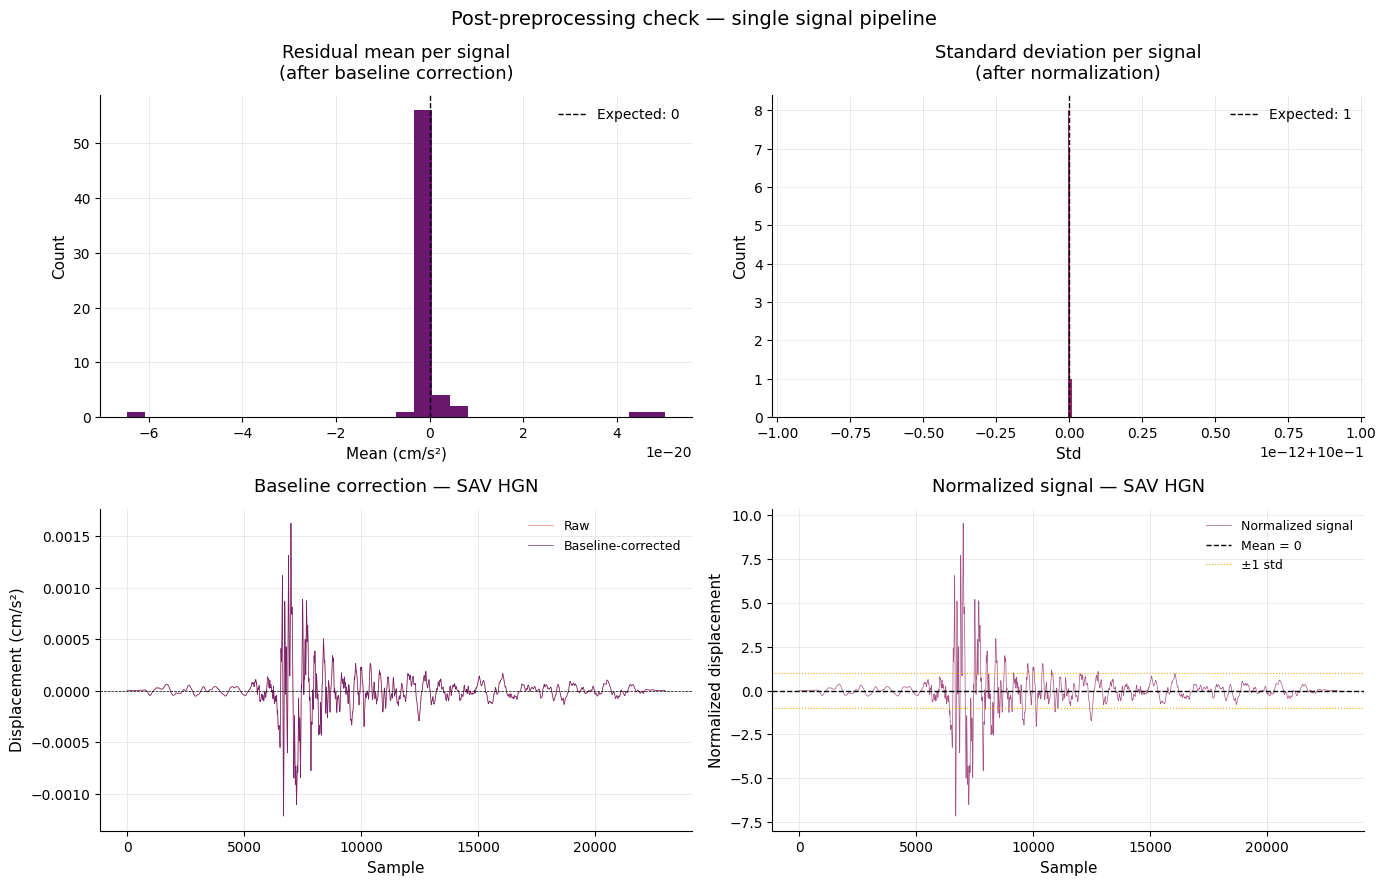

In [45]:
plot_postcheck_pdf(df_signals, df_signals_pdf, signal_column=SIGNAL_COLUMN, output_dir=FIGURES_DIR, prefix=DATA_TYPE[:3])

In [46]:
logger.info("Saving preprocessed data")
try:
    output_path = DATA_PROCESSED / f'{DATA_TYPE[:3]}_preprocessed_pdf.parquet'
    df_signals_pdf.to_parquet(output_path, index=False)
    logger.info(f"Saved: {output_path}")
except Exception as e:
    logger.error(f"Error saving file: {e}")

INFO | Saving preprocessed data
INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01b_signals/displacement/dis_preprocessed_pdf.parquet


In [47]:
plot_station_waveforms(
    df_signals_pdf, 
    signal_column=SIGNAL_COLUMN,
    signal_unit=SIGNAL_UNIT,
    output_dir=FIGURES_DIR / 'waveforms',
    prefix=DATA_TYPE[:3],
    normalized=True
)

Plotting 22 stations...
Saved: dis_SAV_waveforms_normalized.png [HGE, HGN, HGZ]
Saved: dis_REVF_waveforms_normalized.png [HN1, HN2, HNZ]
Saved: dis_EILF_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_MON_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_BHB_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_OGAG_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_SPIF_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_OGMO_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_CAGN_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_MVIF_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_OGSA_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_ISO_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_BRZ_waveforms_normalized.png [HGE, HGN, HGZ]
Saved: dis_CRI_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_MFC_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_SAOF_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_OGS3_waveforms_normalized.png [HNE, HNN, HNZ]
Saved: dis_SUR

['/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/waveforms/dis_SAV_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/waveforms/dis_REVF_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/waveforms/dis_EILF_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/waveforms/dis_MON_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/waveforms/dis_BHB_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/waveforms/dis_OGAG_waveforms_normalized.png',
 '/Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/figures/01b_signals/displacement/waveforms/dis_SPIF_w

## 6. Preprocessing for moment scaling analysis

The moment scaling analysis requires a flexible preprocessing pipeline that can be configured based on the analysis needs. The pipeline offers independent control over three preprocessing steps:

**Available preprocessing options:**

1. **Length filtering** (`filter_length` parameter)
   - If `True`: Retains only signals with ≥ `min_samples` (default: 48,000). Excludes 6 near-field stations (SURF, BRZ, BHB, CRI, SLZ, SAV) whose recordings are shorter.
   - If `False`: Uses all available signals regardless of length.

2. **Baseline correction** (`baseline_correction` parameter)
   - If `True`: Removes per-signal mean to ensure zero baseline. Recommended always, especially for integration.
   - If `False`: Keeps original baseline (may cause drift in integrated signals).

3. **Normalization** (`normalize` parameter)
   - If `True`: Divides each signal by its standard deviation, creating an additional normalized column. Used for PDF analysis and cross-station comparisons.
   - If `False`: Preserves physical units. Required for moment scaling analysis and integration to velocity/displacement.

**Critical choice**: Normalization must be disabled for moment scaling analysis to preserve the physical units needed for integration and scaling computations.

In [48]:
# Display signal length distribution
signal_lengths = df_signals.groupby('file')['sample'].max() + 1
pd.set_option('display.max_rows', None)
print(signal_lengths.sort_values())
pd.reset_option('display.max_rows')

file
query_disp/FR.SURF.00.HNE.D.INT-41004391.DIS.MP.ASC     6000
query_disp/FR.SURF.00.HNZ.D.INT-41004391.DIS.MP.ASC     6000
query_disp/FR.SURF.00.HNN.D.INT-41004391.DIS.MP.ASC     6000
query_disp/IT.BRZ..HGE.D.INT-41004391.DIS.MP.ASC       11001
query_disp/IT.BRZ..HGZ.D.INT-41004391.DIS.MP.ASC       11001
query_disp/IT.BRZ..HGN.D.INT-41004391.DIS.MP.ASC       11001
query_disp/GU.BHB..HNE.D.INT-41004391.DIS.MP.ASC       16601
query_disp/GU.BHB..HNN.D.INT-41004391.DIS.MP.ASC       16601
query_disp/GU.BHB..HNZ.D.INT-41004391.DIS.MP.ASC       16601
query_disp/IT.CRI..HNZ.D.INT-41004391.DIS.MP.ASC       19001
query_disp/IT.CRI..HNE.D.INT-41004391.DIS.MP.ASC       19001
query_disp/IT.CRI..HNN.D.INT-41004391.DIS.MP.ASC       19001
query_disp/IT.SLZ..HNZ.D.INT-41004391.DIS.MP.ASC       20001
query_disp/IT.SLZ..HNN.D.INT-41004391.DIS.MP.ASC       20001
query_disp/IT.SLZ..HNE.D.INT-41004391.DIS.MP.ASC       20001
query_disp/IT.SAV..HGE.D.INT-41004391.DIS.MP.ASC       23001
query_disp/IT.SAV..

### Preprocessing

In [49]:
logger.info("Preprocessing signals — Moment scaling pipeline")
df_signals_scaling = preprocess_signals(
    df_signals,
    signal_column=SIGNAL_COLUMN,
    filter_length=False,
    baseline_correction=True,
    normalize=False
)

INFO | Preprocessing signals — Moment scaling pipeline


Length filtering: DISABLED (using all 66 files)
Baseline correction: max residual mean = 6.46e-20
Normalization: DISABLED (physical units preserved)


### Post-preprocessing check and saving

The preprocessed dataframe is inspected to verify that filtering, baseline correction, and normalization have been applied correctly. The preprocessed data are saved to a parquet file for use in subsequent notebooks

In [50]:
validate_preprocessing(
    df_signals_scaling,
    signal_column=SIGNAL_COLUMN,
    expected_files=66,
    check_normalized=False,
    pipeline_name="Moment scaling"
)

display(df_signals_scaling.head())
display(df_signals_scaling[[SIGNAL_COLUMN]].describe())

INFO | Running quality checks — Moment scaling pipeline
INFO | Baseline corrected: max residual = 6.46e-20
INFO | Not normalized (physical units preserved)
INFO | No NaN in displacement
INFO | No Inf in displacement
INFO | All 66 files retained
INFO | All checks passed. Shape: (2614815, 3)


,file,sample,displacement
0,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,0,2.670531e-07
1,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,1,2.670592e-07
2,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,2,2.670772e-07
3,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,3,2.671073e-07
4,query_disp/IT.SAV..HGN.D.INT-41004391.DIS.MP.ASC,4,2.671494e-07


,displacement
count,2.614815e+06
mean,3.648816e-23
std,1.205047e-03
min,-2.079680e-01
25%,-9.897986e-06
50%,-3.819389e-10
75%,9.910273e-06
max,2.334478e-01


Saved: postcheck_moment_scaling_dis.pdf


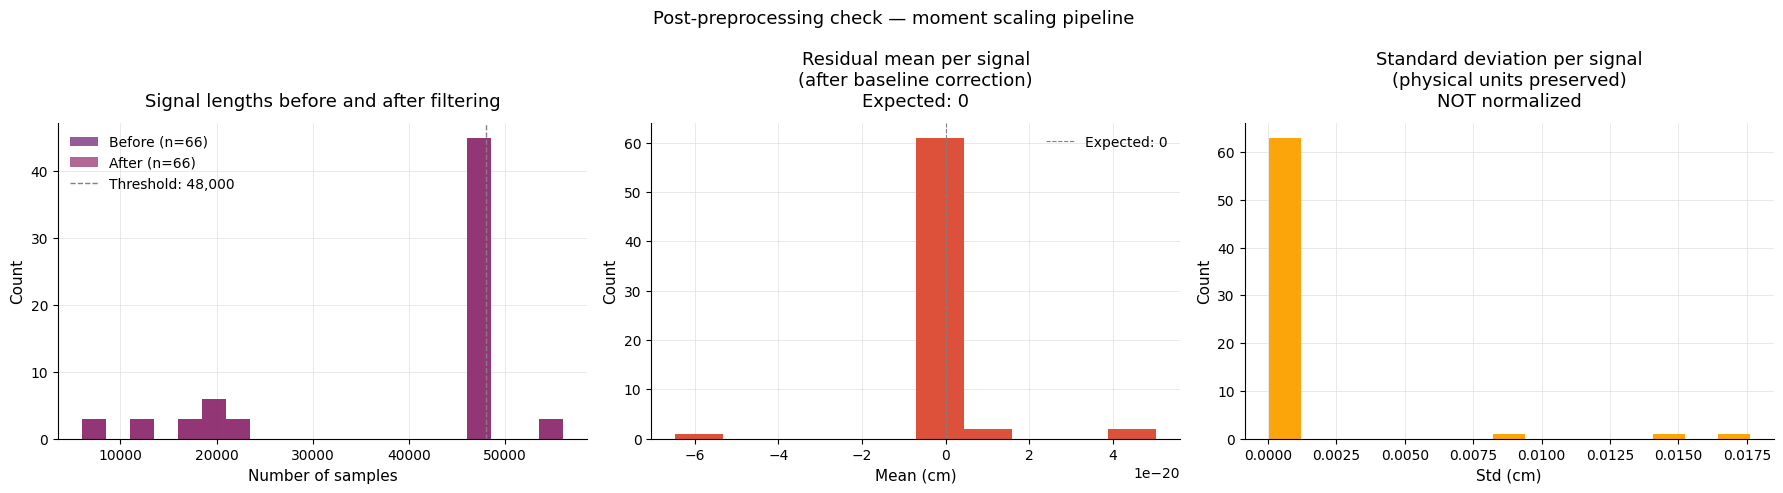

In [51]:
plot_postcheck_moment_scaling(
    df_signals, df_signals_scaling,
    signal_column=SIGNAL_COLUMN,
    signal_unit=SIGNAL_UNIT,
    output_dir=FIGURES_DIR,
    prefix=DATA_TYPE[:3]
)

In [52]:
logger.info("Saving preprocessed data")
try:
    output_path = DATA_PROCESSED / f'{DATA_TYPE[:3]}_preprocessed_scaling.parquet'
    df_signals_scaling.to_parquet(output_path, index=False)
    logger.info(f"Saved: {output_path}")
except Exception as e:
    logger.error(f"Error saving file: {e}")

INFO | Saving preprocessed data
INFO | Saved: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/01b_signals/displacement/dis_preprocessed_scaling.parquet


## Summary

In [53]:
# Variabili per la summary table
signal_lengths_raw = df_signals.groupby('file')['sample'].max() + 1

# Determine normalized column name
normalized_col = f'{SIGNAL_COLUMN}_normalized'

# Pipeline A (PDF) - con normalizzazione
baseline_check_pdf = df_signals_pdf.groupby('file')[SIGNAL_COLUMN].mean()
norm_check_pdf = df_signals_pdf.groupby('file')[normalized_col].std()
bl_max_pdf = baseline_check_pdf.abs().max()
bl_pass_pdf = bl_max_pdf < 1e-10
std_mean_pdf = norm_check_pdf.mean()
std_pass_pdf = ((norm_check_pdf - 1).abs() > 1e-6).sum() == 0
nan_signal_pdf = df_signals_pdf[SIGNAL_COLUMN].isna().sum()
nan_norm_pdf = df_signals_pdf[normalized_col].isna().sum()
inf_signal_pdf = np.isinf(df_signals_pdf[SIGNAL_COLUMN]).sum()
inf_norm_pdf = np.isinf(df_signals_pdf[normalized_col]).sum()
n_files_pdf = df_signals_pdf['file'].nunique()

# Pipeline B (Moment scaling) - SENZA normalizzazione
baseline_check_scaling = df_signals_scaling.groupby('file')[SIGNAL_COLUMN].mean()
bl_max_scaling = baseline_check_scaling.abs().max()
bl_pass_scaling = bl_max_scaling < 1e-10
nan_signal_scaling = df_signals_scaling[SIGNAL_COLUMN].isna().sum()
inf_signal_scaling = np.isinf(df_signals_scaling[SIGNAL_COLUMN]).sum()
n_files_scaling = df_signals_scaling['file'].nunique()
n_excluded = len(signal_lengths_raw) - n_files_scaling

# Summary table
signal_name = SIGNAL_COLUMN.capitalize()
rows = [
    ('Files retained',
     f'{n_files_pdf} / {len(signal_lengths_raw)}',
     f'{n_files_scaling} / {len(signal_lengths_raw)} ({n_excluded} excluded)',
     '—', '—'),
    (f'Max residual mean ({SIGNAL_UNIT})',
     f'{bl_max_pdf:.2e}',
     f'{bl_max_scaling:.2e}',
     '< 1e-10',
     '\\checkmark' if (bl_pass_pdf and bl_pass_scaling) else '\\times'),
    ('Mean std (normalized)',
     f'{std_mean_pdf:.8f}',
     'N/A (not normalized)',
     '$\\approx 1$',
     '\\checkmark' if std_pass_pdf else '\\times'),
    (f'NaN in {SIGNAL_COLUMN}',
     str(nan_signal_pdf),
     str(nan_signal_scaling),
     '0',
     '\\checkmark' if nan_signal_pdf == 0 and nan_signal_scaling == 0 else '\\times'),
    (f'NaN in {SIGNAL_COLUMN}\\_normalized',
     str(nan_norm_pdf),
     'N/A (column not present)',
     '0',
     '\\checkmark' if nan_norm_pdf == 0 else '\\times'),
    (f'Inf in {SIGNAL_COLUMN}',
     str(inf_signal_pdf),
     str(inf_signal_scaling),
     '0',
     '\\checkmark' if inf_signal_pdf == 0 and inf_signal_scaling == 0 else '\\times'),
    (f'Inf in {SIGNAL_COLUMN}\\_normalized',
     str(inf_norm_pdf),
     'N/A (column not present)',
     '0',
     '\\checkmark' if inf_norm_pdf == 0 else '\\times'),
]

df_check = pd.DataFrame(rows, columns=['Check', 'PDF Analysis', 'Moment Scaling', 'Expected', 'Pass'])
display(df_check)

,Check,PDF Analysis,Moment Scaling,Expected,Pass
0,Files retained,66 / 66,66 / 66 (0 excluded),—,—
1,Max residual mean (cm),6.46e-20,6.46e-20,< 1e-10,\checkmark
2,Mean std (normalized),1.00000000,N/A (not normalized),$\approx 1$,\checkmark
3,NaN in displacement,0,0,0,\checkmark
4,NaN in displacement\_normalized,0,N/A (column not present),0,\checkmark
5,Inf in displacement,0,0,0,\checkmark
6,Inf in displacement\_normalized,0,N/A (column not present),0,\checkmark


In [54]:
latex_table = preprocess_checks_to_latex(
    rows, 
    output_path=LATEX_TABLES_DIR / f'preprocess_checks_table_{DATA_TYPE[:3]}.tex'
)
logger.info(f"LaTeX table saved: preprocess_checks_table_{DATA_TYPE[:3]}.tex")

INFO | LaTeX table saved: preprocess_checks_table_dis.tex


Saved to: /Users/giulianaparadiso/Desktop/PoliTo/Tesi/tesi-seismic-analysis/data/processed/latex_tables/displacement/preprocess_checks_table_dis.tex
